# Distribution Conversions

Demo of `to_<name>()` conversions between nested exponential-family distributions in normix:

$$
\text{GIG}\;\supset\;\{\text{Gamma},\;\text{InverseGamma},\;\text{InverseGaussian}\}
\qquad
\text{GH}\;\supset\;\{\text{VG},\;\text{NInvG},\;\text{NIG}\}
$$

The same `to_<x>()` verb implements two mathematically distinct operations:

| Direction | Operation | Notes |
|---|---|---|
| Special $\to$ General (e.g. `Gamma.to_gig`) | **Exact embedding** | Lossless; the special case is a sub-manifold |
| General $\to$ Special (e.g. `GIG.to_gamma`) | **KL projection** | Closest member of the target family in $D_{\mathrm{KL}}(p\,\|\,q)$; matches expected target sufficient statistics |

When the source already lies on the special-case manifold both operations agree, so any round-trip `source.to_<general>().to_<source>()` is a numerical identity (up to the digamma Newton tolerance for Gamma/InvGamma, exact for InvGauss).

Theory: `dev-notes/tech_notes/distribution_conversions.md`. Tests: `tests/test_distribution_conversions.py`.

In [1]:
import os
os.environ.setdefault("JAX_ENABLE_X64", "1")

import numpy as np
import jax, jax.numpy as jnp
import matplotlib.pyplot as plt
from scipy import stats
jax.config.update("jax_enable_x64", True)

from normix.distributions import (
    Gamma, InverseGamma, InverseGaussian, GIG,
    GeneralizedHyperbolic, VarianceGamma,
    NormalInverseGamma, NormalInverseGaussian,
)
from normix.utils.plotting import FIG_W, FIG_H

np.set_printoptions(precision=6, suppress=True)
plt.rcParams.update({"font.size": 11, "figure.dpi": 110})
%matplotlib inline

## 1. Subordinator level: GIG $\leftrightarrow$ \{Gamma, InverseGamma, InverseGaussian\}

**Lift table** (exact algebraic embedding):

| Source | GIG image |
|---|---|
| Gamma$(\alpha,\beta)$ | $(p,a,b) = (\alpha,\,2\beta,\,0)$ |
| InverseGamma$(\alpha,\beta)$ | $(p,a,b) = (-\alpha,\,0,\,2\beta)$ |
| InverseGaussian$(\mu,\lambda)$ | $(p,a,b) = (-1/2,\,\lambda/\mu^2,\,\lambda)$ |

**Projection table** (matched expected sufficient stats from `eta = (E[log X], E[1/X], E[X])`):

| Target | Target $\eta$ from GIG $\eta$ |
|---|---|
| Gamma | $(\eta_1,\,\eta_3)$ |
| InverseGamma | $(-\eta_2,\,\eta_1)$ |
| InverseGaussian | $(\eta_3,\,\eta_2)$ |

### 1.1 Lift + project round-trips on the special-case manifold

`Gamma -> GIG -> Gamma` should recover $(\alpha, \beta)$ exactly (modulo Newton tolerance).

In [2]:
def show_roundtrip(label, original, lifted_attrs, projected, source_attrs):
    """Print parameters before/after a lift+project round-trip."""
    print(f"--- {label} ---")
    print(f"  original   : {source_attrs(original)}")
    print(f"  lifted GIG : p={float(lifted_attrs.p):.6f}, a={float(lifted_attrs.a):.6f}, b={float(lifted_attrs.b):.6f}")
    print(f"  recovered  : {source_attrs(projected)}")
    print()

g = Gamma(alpha=2.5, beta=1.5)
show_roundtrip(
    "Gamma -> GIG -> Gamma",
    g, g.to_gig(), g.to_gig().to_gamma(),
    lambda d: f"alpha={float(d.alpha):.6f}, beta={float(d.beta):.6f}",
)

ig = InverseGamma(alpha=3.0, beta=2.0)
show_roundtrip(
    "InverseGamma -> GIG -> InverseGamma",
    ig, ig.to_gig(), ig.to_gig().to_inverse_gamma(),
    lambda d: f"alpha={float(d.alpha):.6f}, beta={float(d.beta):.6f}",
)

igauss = InverseGaussian(mu=1.5, lam=2.0)
show_roundtrip(
    "InverseGaussian -> GIG -> InverseGaussian",
    igauss, igauss.to_gig(), igauss.to_gig().to_inverse_gaussian(),
    lambda d: f"mu={float(d.mu):.6f}, lam={float(d.lam):.6f}",
)

--- Gamma -> GIG -> Gamma ---
  original   : alpha=2.500000, beta=1.500000
  lifted GIG : p=2.500000, a=3.000000, b=0.000000
  recovered  : alpha=2.500000, beta=1.500000

--- InverseGamma -> GIG -> InverseGamma ---
  original   : alpha=3.000000, beta=2.000000
  lifted GIG : p=-3.000000, a=0.000000, b=4.000000
  recovered  : alpha=3.000000, beta=2.000000

--- InverseGaussian -> GIG -> InverseGaussian ---
  original   : mu=1.500000, lam=2.000000
  lifted GIG : p=-0.500000, a=0.888889, b=2.000000
  recovered  : mu=1.500000, lam=2.000000



### 1.2 Visual check: lifted GIG density matches the source

If the lift is correct, the GIG density and the special-case density should overlap (the GIG handles the boundary $b=0$ or $a=0$ via its degenerate branch).

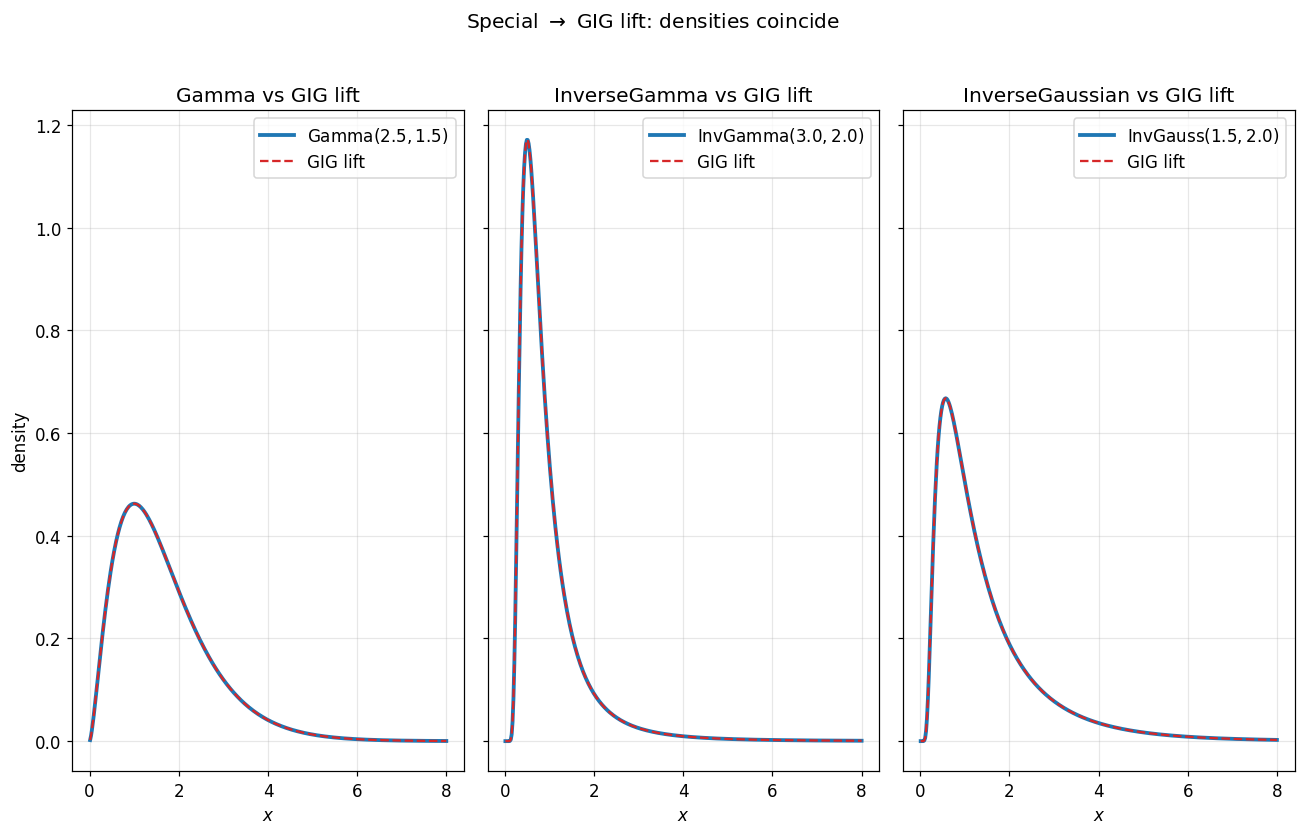

In [3]:
x = jnp.linspace(0.01, 8.0, 400)

fig, axes = plt.subplots(1, 3, figsize=(FIG_W, FIG_H), sharey=True)

# --- Gamma ---
g = Gamma(alpha=2.5, beta=1.5)
ax = axes[0]
ax.plot(x, jax.vmap(g.pdf)(x), lw=2.5, label="Gamma$(2.5, 1.5)$")
ax.plot(x, jax.vmap(g.to_gig().pdf)(x), "--", lw=1.5, color="tab:red", label="GIG lift")
ax.set_title("Gamma vs GIG lift")
ax.set_xlabel("$x$")
ax.set_ylabel("density")
ax.legend()
ax.grid(alpha=0.3)

# --- InverseGamma ---
ig = InverseGamma(alpha=3.0, beta=2.0)
ax = axes[1]
ax.plot(x, jax.vmap(ig.pdf)(x), lw=2.5, label="InvGamma$(3.0, 2.0)$")
ax.plot(x, jax.vmap(ig.to_gig().pdf)(x), "--", lw=1.5, color="tab:red", label="GIG lift")
ax.set_title("InverseGamma vs GIG lift")
ax.set_xlabel("$x$")
ax.legend()
ax.grid(alpha=0.3)

# --- InverseGaussian ---
igauss = InverseGaussian(mu=1.5, lam=2.0)
ax = axes[2]
ax.plot(x, jax.vmap(igauss.pdf)(x), lw=2.5, label="InvGauss$(1.5, 2.0)$")
ax.plot(x, jax.vmap(igauss.to_gig().pdf)(x), "--", lw=1.5, color="tab:red", label="GIG lift")
ax.set_title("InverseGaussian vs GIG lift")
ax.set_xlabel("$x$")
ax.legend()
ax.grid(alpha=0.3)

fig.suptitle("Special $\\to$ GIG lift: densities coincide", y=1.02)
fig.tight_layout()
plt.show()

### 1.3 KL projection of a generic GIG

Take a GIG with $p, a, b$ all in the interior (so it's not on any special-case sub-manifold) and project it onto each special-case family. The projections do *not* coincide with the source — they are the closest members of the target families in KL.

source GIG    : p=1.0000, a=2.0000, b=1.5000
  -> Gamma     : alpha=2.5491, beta=1.5110
  -> InvGamma  : alpha=2.3609, beta=2.5772
  -> InvGauss  : mu=1.6870, lam=3.0932


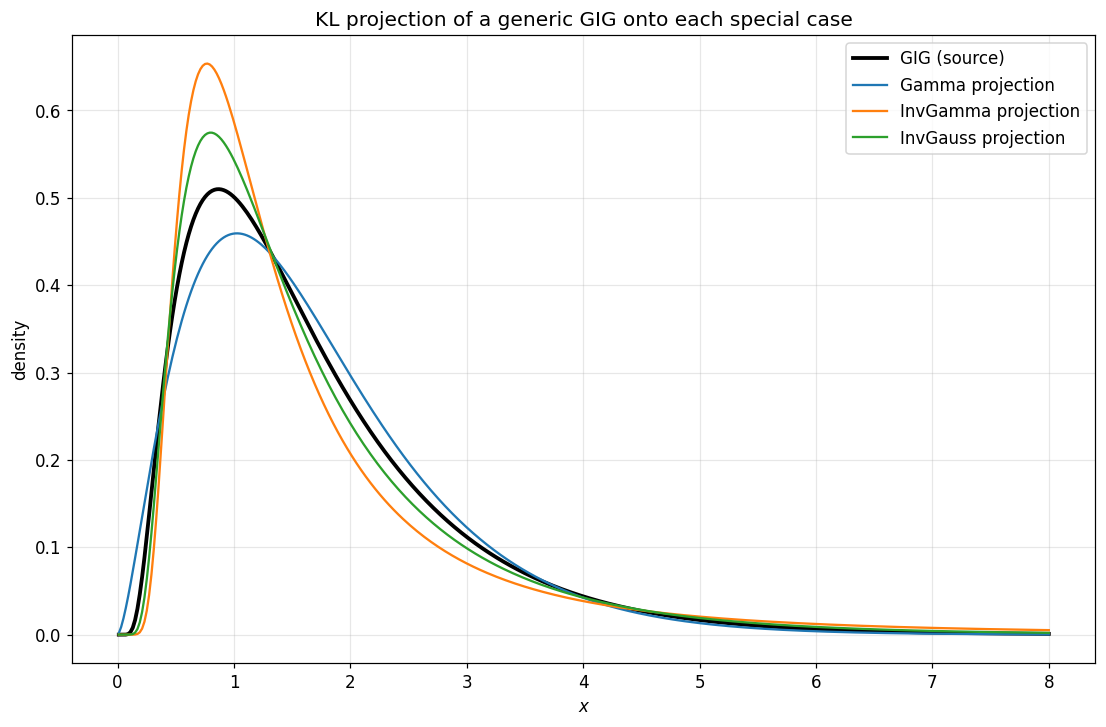

In [4]:
gig = GIG(p=1.0, a=2.0, b=1.5)
g_proj = gig.to_gamma()
ig_proj = gig.to_inverse_gamma()
igauss_proj = gig.to_inverse_gaussian()

print(f"source GIG    : p={float(gig.p):.4f}, a={float(gig.a):.4f}, b={float(gig.b):.4f}")
print(f"  -> Gamma     : alpha={float(g_proj.alpha):.4f}, beta={float(g_proj.beta):.4f}")
print(f"  -> InvGamma  : alpha={float(ig_proj.alpha):.4f}, beta={float(ig_proj.beta):.4f}")
print(f"  -> InvGauss  : mu={float(igauss_proj.mu):.4f}, lam={float(igauss_proj.lam):.4f}")

x = jnp.linspace(0.01, 8.0, 400)
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.plot(x, jax.vmap(gig.pdf)(x), lw=2.5, color="black", label="GIG (source)")
ax.plot(x, jax.vmap(g_proj.pdf)(x), lw=1.5, label="Gamma projection")
ax.plot(x, jax.vmap(ig_proj.pdf)(x), lw=1.5, label="InvGamma projection")
ax.plot(x, jax.vmap(igauss_proj.pdf)(x), lw=1.5, label="InvGauss projection")
ax.set_title("KL projection of a generic GIG onto each special case")
ax.set_xlabel("$x$")
ax.set_ylabel("density")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### 1.4 The projection minimises KL

Sweep the projected Gamma's $\alpha$ around the optimum and compute the cross-family KL by Monte Carlo. The projected $\alpha$ should sit at the empirical minimum.

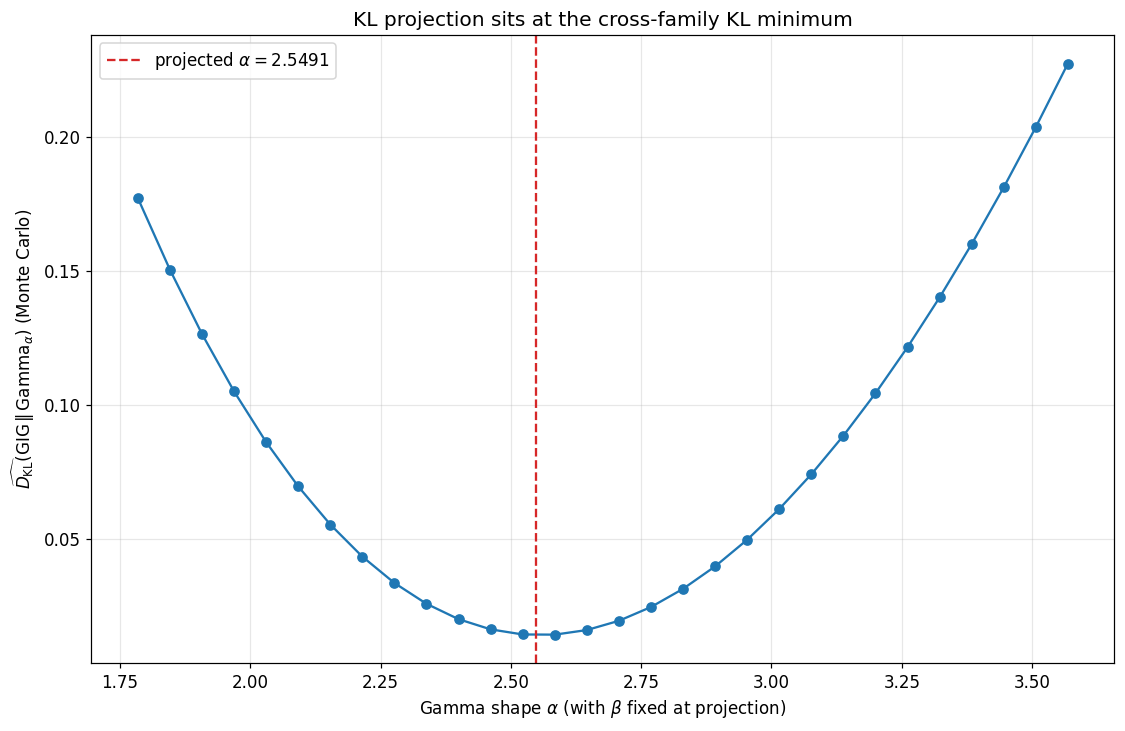

In [5]:
n_samples = 30_000
samples = gig.rvs(n=n_samples, seed=0, method="devroye")
log_p = jax.vmap(gig.log_prob)(samples)

alpha_grid = jnp.linspace(float(g_proj.alpha) * 0.7,
                          float(g_proj.alpha) * 1.4, 30)
kl_grid = []
for a_val in alpha_grid:
    g_test = Gamma(alpha=float(a_val), beta=float(g_proj.beta))
    log_q = jax.vmap(g_test.log_prob)(samples)
    kl_grid.append(float(jnp.mean(log_p - log_q)))
kl_grid = np.array(kl_grid)

fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.plot(alpha_grid, kl_grid, marker="o")
ax.axvline(float(g_proj.alpha), color="tab:red", linestyle="--",
           label=f"projected $\\alpha = {float(g_proj.alpha):.4f}$")
ax.set_xlabel(r"Gamma shape $\alpha$ (with $\beta$ fixed at projection)")
ax.set_ylabel(r"$\widehat{D_{\mathrm{KL}}}(\mathrm{GIG}\,\|\,\mathrm{Gamma}_\alpha)$ (Monte Carlo)")
ax.set_title("KL projection sits at the cross-family KL minimum")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

## 2. Joint level: GH $\leftrightarrow$ \{VG, NInvG, NIG\}

Each `JointXxx` distribution shares the same Normal block $f(x|y) = \mathcal{N}(\mu + \gamma y, \Sigma y)$ and differs only in the subordinator $f_Y$. Joint conversions therefore reduce to **subordinator conversions only**:

$$
D_{\mathrm{KL}}(\text{JointGH}\,\|\,\text{JointVG}) \;=\; D_{\mathrm{KL}}(\text{GIG}\,\|\,\text{Gamma})
$$

because $f(x|y)$ is identical between the two joint distributions. The marginal-layer wrappers (`GeneralizedHyperbolic.to_variance_gamma`, etc.) just re-wrap the joint conversion.

### 2.1 Round-trip: special $\to$ GH $\to$ special preserves the model

The Normal block is preserved exactly (bit-for-bit) and the subordinator is recovered up to the digamma Newton tolerance. KL between original and round-trip is essentially machine-epsilon.

In [6]:
mu = jnp.array([0.1, -0.2])
gamma = jnp.array([0.05, 0.1])
sigma = jnp.array([[1.0, 0.3], [0.3, 1.5]])

vg = VarianceGamma.from_classical(mu=mu, gamma=gamma, sigma=sigma, alpha=2.5, beta=1.5)
vg_back = vg.to_generalized_hyperbolic().to_variance_gamma()
kl_vg = float(vg.kl_divergence(vg_back))
print(f"VG round-trip:    KL(orig || rt) = {kl_vg:.3e}")

nig = NormalInverseGaussian.from_classical(mu=mu, gamma=gamma, sigma=sigma, mu_ig=1.5, lam=2.0)
nig_back = nig.to_generalized_hyperbolic().to_normal_inverse_gaussian()
kl_nig = float(nig.kl_divergence(nig_back))
print(f"NIG round-trip:   KL(orig || rt) = {kl_nig:.3e}")

ninvg = NormalInverseGamma.from_classical(mu=mu, gamma=gamma, sigma=sigma, alpha=3.0, beta=2.0)
ninvg_back = ninvg.to_generalized_hyperbolic().to_normal_inverse_gamma()
kl_ninvg = float(ninvg.kl_divergence(ninvg_back))
print(f"NInvG round-trip: KL(orig || rt) = {kl_ninvg:.3e}")

VG round-trip:    KL(orig || rt) = -2.034e-16


NIG round-trip:   KL(orig || rt) = 1.388e-16


NInvG round-trip: KL(orig || rt) = 1.057e-15


### 2.2 KL projection of a true GH onto each special case

Build a 1D GH with all three GIG parameters in the interior, project to each cousin, and overlay the four marginal densities.

Projected subordinator parameters:
  VG:    alpha=2.4836,  beta=1.2975
  NInvG: alpha=2.1808, beta=2.6325
  NIG:   mu_ig=1.9142,  lam=3.2678


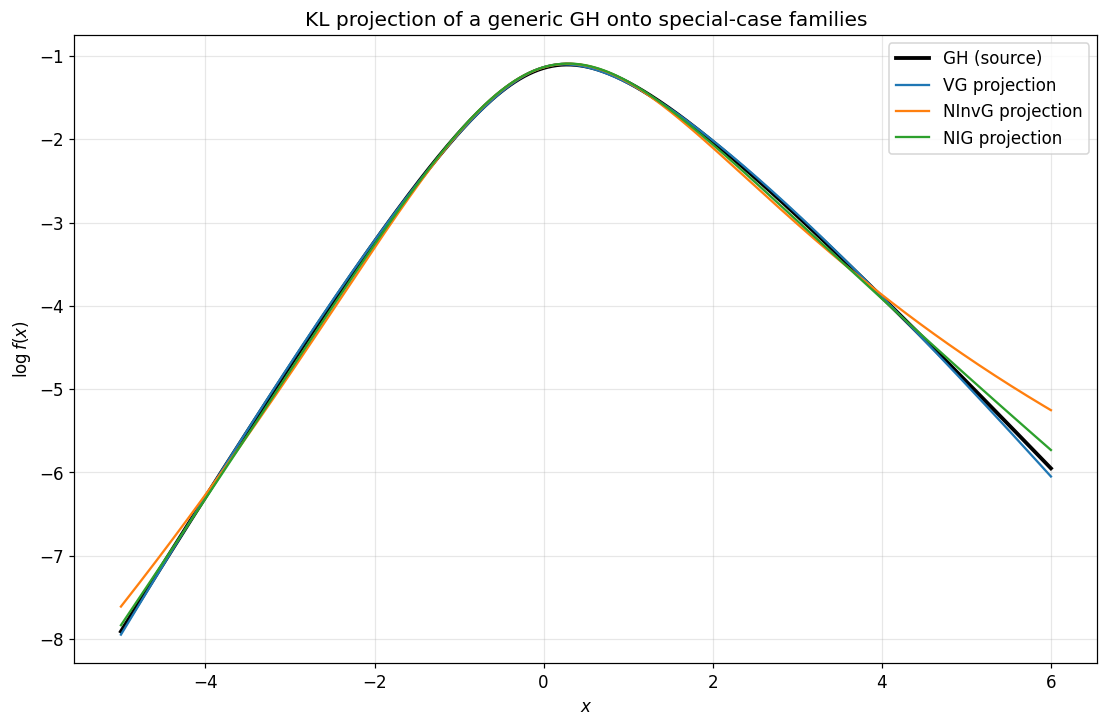

In [7]:
gh = GeneralizedHyperbolic.from_classical(
    mu=jnp.array([0.0]), gamma=jnp.array([0.3]),
    sigma=jnp.array([[1.0]]),
    p=1.5, a=2.0, b=1.0,
)

vg_proj = gh.to_variance_gamma()
ninvg_proj = gh.to_normal_inverse_gamma()
nig_proj = gh.to_normal_inverse_gaussian()

print("Projected subordinator parameters:")
print(f"  VG:    alpha={float(vg_proj.alpha):.4f},  beta={float(vg_proj.beta):.4f}")
print(f"  NInvG: alpha={float(ninvg_proj.alpha):.4f}, beta={float(ninvg_proj.beta):.4f}")
print(f"  NIG:   mu_ig={float(nig_proj.mu_ig):.4f},  lam={float(nig_proj.lam):.4f}")

x = jnp.linspace(-5.0, 6.0, 400)[:, None]
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.plot(x[:, 0], jax.vmap(gh.log_prob)(x), lw=2.5, color="black",
        label="GH (source)")
ax.plot(x[:, 0], jax.vmap(vg_proj.log_prob)(x), lw=1.5, label="VG projection")
ax.plot(x[:, 0], jax.vmap(ninvg_proj.log_prob)(x), lw=1.5, label="NInvG projection")
ax.plot(x[:, 0], jax.vmap(nig_proj.log_prob)(x), lw=1.5, label="NIG projection")
ax.set_title("KL projection of a generic GH onto special-case families")
ax.set_xlabel("$x$")
ax.set_ylabel("$\\log f(x)$")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

### 2.3 Approximation quality

Estimate $D_{\mathrm{KL}}(\text{GH}\,\|\,\text{projection})$ by Monte Carlo for each target family.

In [8]:
n_samples = 20_000
X, _ = gh._joint.rvs(n=n_samples, seed=0)
log_p = jax.vmap(gh.log_prob)(X)

rows = []
for name, q in [("VG", vg_proj), ("NInvG", ninvg_proj), ("NIG", nig_proj)]:
    log_q = jax.vmap(q.log_prob)(X)
    kl = float(jnp.mean(log_p - log_q))
    rows.append((name, kl))

print("Monte Carlo cross-family KL (lower is closer to the source GH):\n")
print(f"  {'Target':<8}  {'KL(GH || target)':>20}")
print("  " + "-" * 32)
for name, kl in rows:
    print(f"  {name:<8}  {kl:>20.6f}")

Monte Carlo cross-family KL (lower is closer to the source GH):

  Target        KL(GH || target)
  --------------------------------
  VG                   -0.000078
  NInvG                 0.008788
  NIG                   0.000901


## 3. Summary

- **Lift** (special $\to$ general): exact algebraic embedding. Zero approximation error.
- **Project** (general $\to$ special): KL projection via moment matching on the target's sufficient statistics.
- **Joint conversions** are governed entirely by the subordinator: the Normal block is invariant.
- **Round-trip**: lifting then projecting is the identity (up to digamma Newton tolerance for Gamma/InvGamma; exact for InvGauss).

See `dev-notes/tech_notes/distribution_conversions.md` for derivations and the floating-point caveat for the InverseGaussian projection near the Gamma limit.